# IFN680 Project 4 - AI Auditing - Case 1 - clean-shaven detector, studio to mobile

**Student 1:** Karan Rooprai  **Student ID:** n12498122
**Student 2:** Nhu Hieu Nguyen  **Student ID:** n12194778

A grooming application needs to tell clean-shaven faces from faces that are not. The
engineering team trained and validated the classifier on studio-quality photographs and reported
near-perfect accuracy on the internal test set. Once the model shipped inside a mobile app its
accuracy fell sharply and users report frequent failures. The question the brief asks is what
happened in the transition from studio to mobile app.

**What this notebook does.** It is an audit, not a repair: the delivered weights are loaded and
never changed, and nothing is retrained. The two supplied test sets are compared on the inputs
themselves before any prediction is made, then on confusion matrices, precision, recall and F1,
predicted-probability distributions, ROC and AUC, reliability and expected calibration error, the
accuracy of the model's most confident predictions, and class activation maps. Section 12 runs the
experiment specific to this case, which is the one that distinguishes the diagnosis in Section 13
from the alternatives.

## 1. Setup

In [1]:
import hashlib
import os
import pickle

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
from sklearn.metrics import roc_curve, auc

# Fixed seeds: every sample of images shown below is drawn with a generator seeded here, so the
# figures in the report are the ones this notebook regenerates rather than a fresh random draw.
torch.manual_seed(0)
np.random.seed(0)

# The brief asks for the GPU environment. The model still runs on CPU if no GPU is present, which
# is what makes this notebook portable between the Hub GPU node and a marker's laptop.
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(f'device      : {device}')
print(f'torch       : {torch.__version__}')
print(f'torchvision : {torchvision.__version__}')
print(f'numpy       : {np.__version__}')

device      : cpu
torch       : 2.13.0+cpu
torchvision : 0.28.0+cpu
numpy       : 2.5.1


## 2. Locate the delivered model and data

All three cases ship a checkpoint called `resnet_frozen_best.pth`, so the notebook verifies which
one it loaded instead of trusting the file name.

In [2]:
CASE = 1
POSITIVE_CLASS = 'clean-shaven'

# The three cases ship checkpoints with the SAME file name but different weights. Searching the
# case-scoped folder before the bare name stops a flat unzip from silently loading another case's
# model, and the digest check turns a wrong file into an immediate, readable failure rather than
# a set of plausible but wrong numbers.
EXPECTED_MD5 = 'b618824686d01bae29d9ab4149d4b642'

def find(relative_paths):
    """Return the first candidate path that exists, else None."""
    for path in relative_paths:
        if os.path.exists(path):
            return path
    return None

DATA_ROOT = find([f'Case{CASE}/Case{CASE}Dataset',
                  f'Case{CASE}Dataset',
                  os.path.expanduser(f'~/Assessment4/Case{CASE}/Case{CASE}Dataset'),
                  os.path.expanduser(f'~/Assessment4/Case{CASE}Dataset')])
WEIGHTS = find([f'Case{CASE}/resnet_frozen_best.pth',
                os.path.join(os.path.dirname(DATA_ROOT or '.'), 'resnet_frozen_best.pth'),
                'resnet_frozen_best.pth',
                os.path.expanduser(f'~/Assessment4/Case{CASE}/resnet_frozen_best.pth')])

assert DATA_ROOT, (f'Case{CASE}Dataset not found. Unzip it beside this notebook as '
                   f'Case{CASE}/Case{CASE}Dataset/ and re-run.')
assert WEIGHTS, f'resnet_frozen_best.pth for case {CASE} not found.'
digest = hashlib.md5(open(WEIGHTS, 'rb').read()).hexdigest()
assert digest == EXPECTED_MD5, (f'{WEIGHTS} is not the case {CASE} checkpoint '
                                f'(md5 {digest}, expected {EXPECTED_MD5}).')
print(f'data    : {DATA_ROOT}')
print(f'weights : {WEIGHTS}  (md5 verified)')

data    : Case1/Case1Dataset
weights : Case1/resnet_frozen_best.pth  (md5 verified)


## 3. The two test sets

`test_internal` is the validation set the model was developed against; `test_external` is the field
sample where it fails. `positive` means **clean-shaven**.

In [3]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD = (0.229, 0.224, 0.225)

# The delivered start-up notebook resizes after ToTensor. antialias is pinned explicitly because
# the default for tensor input changed in torchvision 0.17, and an unpinned resize would make the
# reported numbers depend on the marker's library version rather than on the model.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Resize((224, 224), antialias=True),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

datasets = {split: torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, f'test_{split}'),
                                                    transform=transform)
            for split in ('internal', 'external')}
loaders = {split: torch.utils.data.DataLoader(ds, batch_size=32, shuffle=False, num_workers=0)
           for split, ds in datasets.items()}

# ImageFolder assigns indices alphabetically, so negative is 0 and positive is 1. The assert makes
# that a checked fact rather than an assumption every later metric silently depends on.
class_names = datasets['internal'].classes
assert class_names == ['negative', 'positive'], class_names
print(f"class index order : {class_names}   (positive = {POSITIVE_CLASS})")
for split, ds in datasets.items():
    labels = np.array(ds.targets)
    print(f'{split:9s} n={len(ds):4d}   negative={int((labels == 0).sum()):4d}   '
          f'positive={int((labels == 1).sum()):4d}')

class index order : ['negative', 'positive']   (positive = clean-shaven)
internal  n= 840   negative= 420   positive= 420
external  n= 740   negative= 370   positive= 370


## 4. Audit the inputs before the model

An audit that starts at the confusion matrix can only describe the failure. The question is what
differs between the data the model was validated on and the data it met in deployment, and that is
a property of the images, measurable without a single prediction. Sharpness is summarised by the
variance of the Laplacian, which responds to fine detail and ignores overall level; brightness and
contrast are the mean and standard deviation of pixel intensity.

In [4]:
from PIL import Image

def laplacian_variance(gray):
    """Variance of the discrete Laplacian: a standard, scale-free measure of image sharpness.

    Blurring removes high-frequency detail, which is exactly what the Laplacian responds to, so
    this number falls when an image is smoothed and is insensitive to a change in overall level.
    """
    inner = gray[1:-1, 1:-1]
    lap = (gray[:-2, 1:-1] + gray[2:, 1:-1] + gray[1:-1, :-2] + gray[1:-1, 2:] - 4 * inner)
    return float(lap.var())

def folder_statistics(paths, sample=120, seed=0):
    """Sharpness, brightness, contrast and stored size over a fixed random sample of a folder."""
    rng = np.random.default_rng(seed)
    chosen = [paths[i] for i in rng.choice(len(paths), min(sample, len(paths)), replace=False)]
    sharp, bright, contrast, nbytes, sizes = [], [], [], [], set()
    for path in chosen:
        image = Image.open(path)
        sizes.add(image.size)
        rgb = np.asarray(image.convert('RGB'), dtype=float) / 255.0
        sharp.append(laplacian_variance(np.asarray(image.convert('L'), dtype=float) / 255.0))
        bright.append(rgb.mean())
        contrast.append(rgb.std())
        nbytes.append(os.path.getsize(path))
    return dict(n=len(paths), sharpness=float(np.mean(sharp)), brightness=float(np.mean(bright)),
                contrast=float(np.mean(contrast)), kilobytes=float(np.mean(nbytes)) / 1024,
                sizes=sorted(sizes))

In [5]:
# One row per class folder. The model never sees these raw values; they describe the inputs, which
# is what an audit needs before it looks at any prediction.
paths_by_folder = {}
for split, ds in datasets.items():
    for index, name in enumerate(class_names):
        paths_by_folder[(split, name)] = [p for p, y in ds.samples if y == index]

stats = {key: folder_statistics(paths) for key, paths in paths_by_folder.items()}
print(f"{'folder':26s}{'n':>5}{'sharpness':>12}{'brightness':>12}{'contrast':>10}{'KB':>8}  pixels")
for key in sorted(stats):
    s = stats[key]
    print(f"{key[0] + '/' + key[1]:26s}{s['n']:5d}{s['sharpness']:12.5f}{s['brightness']:12.3f}"
          f"{s['contrast']:10.3f}{s['kilobytes']:8.1f}  {s['sizes'][0][0]}x{s['sizes'][0][1]}")

internal_sharp = np.mean([stats[('internal', c)]['sharpness'] for c in class_names])
external_sharp = np.mean([stats[('external', c)]['sharpness'] for c in class_names])
internal_bright = np.mean([stats[('internal', c)]['brightness'] for c in class_names])
external_bright = np.mean([stats[('external', c)]['brightness'] for c in class_names])
print(f'\nsharpness  internal={internal_sharp:.5f}  external={external_sharp:.5f}  '
      f'ratio={internal_sharp / external_sharp:.1f}x')
print(f'brightness internal={internal_bright:.3f}  external={external_bright:.3f}  '
      f'shift={external_bright - internal_bright:+.3f}')

folder                        n   sharpness  brightness  contrast      KB  pixels
external/negative           370     0.00114       0.689     0.243     4.5  178x218
external/positive           370     0.00104       0.708     0.245     4.5  178x218
internal/negative           420     0.01124       0.437     0.258     6.5  178x218
internal/positive           420     0.01029       0.436     0.260     6.5  178x218

sharpness  internal=0.01077  external=0.00109  ratio=9.9x
brightness internal=0.437  external=0.699  shift=+0.262


### 4.1 Look at the images

Summary statistics can only answer questions that were asked. Displaying every folder is what
catches a difference nobody thought to measure.

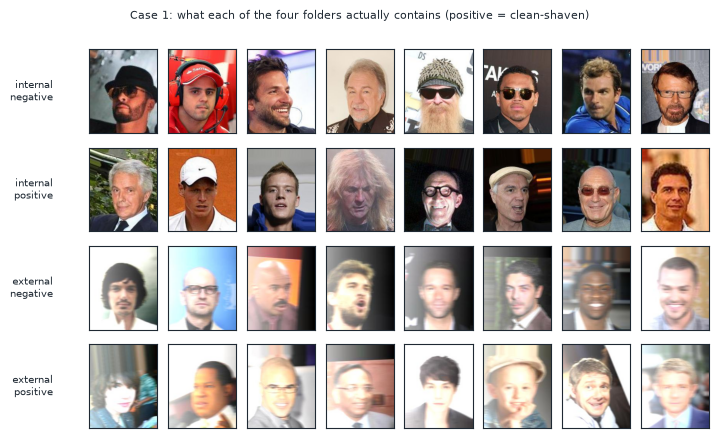

In [6]:
INK, ACCENT, WARM, MUTED, GREEN = '#1f2933', '#2f6f9f', '#c1553b', '#7b8794', '#3f7d58'
plt.rcParams.update({'font.size': 7, 'axes.edgecolor': INK, 'axes.labelcolor': INK,
                     'text.color': INK, 'xtick.color': INK, 'ytick.color': INK,
                     'figure.facecolor': 'white'})

def show_folder(ax_row, split, name, columns, seed=11):
    """Draw one row of raw images from a single class folder."""
    paths = paths_by_folder[(split, name)]
    rng = np.random.default_rng(seed)
    for ax, index in zip(ax_row, rng.choice(len(paths), columns, replace=False)):
        ax.imshow(Image.open(paths[index]))
        ax.set_xticks([]); ax.set_yticks([])

COLUMNS = 8
folders = [(s, c) for s in ('internal', 'external') for c in class_names]
figure, axes = plt.subplots(4, COLUMNS, figsize=(7.2, 4.4))
for row, (split, name) in enumerate(folders):
    show_folder(axes[row], split, name, COLUMNS)
    label = f'{split}\n{name}'
    axes[row][0].set_ylabel(label, fontsize=7, rotation=0, ha='right', va='center', labelpad=26)
figure.suptitle(f'Case {CASE}: what each of the four folders actually contains '
                f'(positive = {POSITIVE_CLASS})', fontsize=8)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.97))
figure.savefig(f'case{CASE}_composition.png', dpi=150, bbox_inches='tight')
figure.savefig(f'case{CASE}_composition.pdf', bbox_inches='tight')
plt.show()

## 5. The delivered model

A ResNet-18 with its 1000-way ImageNet head replaced by a two-way one, trained by the previous
team. Loaded once, put in evaluation mode, and left unmodified for the rest of the notebook.

In [7]:
def setup_model(model, num_classes, freeze_backbone=False):
    """Swap in a head with num_classes outputs. Reproduced from the supplied start-up notebook."""
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    if freeze_backbone:
        for parameter in model.parameters():
            parameter.requires_grad = False
        for parameter in model.fc.parameters():
            parameter.requires_grad = True
    return model

# weights=None builds the architecture without downloading ImageNet weights: every parameter is
# replaced by the delivered checkpoint on the next line. Nothing here trains or alters the model.
model = setup_model(torchvision.models.resnet18(weights=None), 2)
model.load_state_dict(torch.load(WEIGHTS, map_location=device, weights_only=True))
model = model.to(device).eval()
print(f'loaded ResNet-18 with a {model.fc.out_features}-way head, in eval mode')

loaded ResNet-18 with a 2-way head, in eval mode


## 6. Predictions

One pass over each split, recording the true label and the probability assigned to the positive
class. Every number and figure below is computed from these two arrays.

In [8]:
@torch.no_grad()
def collect(loader):
    """Return ground-truth labels and P(positive) for every image the loader yields, in order."""
    labels, probabilities = [], []
    for inputs, targets in loader:
        probabilities.append(torch.softmax(model(inputs.to(device)), dim=1)[:, 1].cpu().numpy())
        labels.append(targets.numpy())
    return np.concatenate(labels), np.concatenate(probabilities)

# Every metric, figure and table below is derived from these two arrays, so the audit is fully
# reproducible from the pickle even without a GPU.
results = {}
for split, loader in loaders.items():
    labels, probabilities = collect(loader)
    results[split] = {'labels': labels, 'prob_pos': probabilities}
    print(f'{split:9s} n={len(labels):4d}   '
          f'accuracy={(((probabilities > 0.5).astype(int) == labels).mean()):.4f}')

with open(f'case{CASE}_predictions.pkl', 'wb') as handle:
    pickle.dump(results, handle)
print(f'wrote case{CASE}_predictions.pkl')

internal  n= 840   accuracy=0.9369


external  n= 740   accuracy=0.6189
wrote case1_predictions.pkl


## 7. Confusion matrices and per-split metrics

Accuracy compresses two very different quantities into one. Precision and recall separate them,
and their gap is what shows whether the errors fall on one side.

In [9]:
def counts(labels, probabilities, threshold=0.5):
    """True/false positive and negative counts at a decision threshold."""
    predicted, actual = probabilities > threshold, labels.astype(bool)
    return (int((predicted & actual).sum()), int((predicted & ~actual).sum()),
            int((~predicted & ~actual).sum()), int((~predicted & actual).sum()))

def metrics(labels, probabilities):
    """Accuracy, precision, recall, F1, AUC and expected calibration error for one split."""
    tp, fp, tn, fn = counts(labels, probabilities)
    accuracy = (tp + tn) / (tp + fp + tn + fn)
    precision = tp / (tp + fp) if tp + fp else float('nan')
    recall = tp / (tp + fn) if tp + fn else float('nan')
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else float('nan')
    false_positive_rate, true_positive_rate, _ = roc_curve(labels, probabilities)
    return dict(acc=accuracy, prec=precision, rec=recall, f1=f1,
                auc=auc(false_positive_rate, true_positive_rate), ece=expected_calibration_error(
                    labels, probabilities)[3], tp=tp, fp=fp, tn=tn, fn=fn)

def expected_calibration_error(labels, probabilities, bins=10):
    """Bin predictions by confidence and compare accuracy against confidence within each bin.

    Confidence is max(p, 1-p): how sure the model is of whichever class it chose. A calibrated
    model is right about c of the time among predictions made with confidence c, so ECE is the
    sample-weighted gap between the two, and it is the number a reliability diagram summarises.
    """
    confidence = np.maximum(probabilities, 1 - probabilities)
    correct = ((probabilities > 0.5).astype(int) == labels).astype(float)
    edges = np.linspace(0, 1, bins + 1)
    which = np.clip(np.digitize(confidence, edges) - 1, 0, bins - 1)
    accuracy = np.array([correct[which == b].mean() if (which == b).any() else np.nan
                         for b in range(bins)])
    mean_confidence = np.array([confidence[which == b].mean() if (which == b).any() else np.nan
                                for b in range(bins)])
    weight = np.array([(which == b).sum() for b in range(bins)], dtype=float)
    return mean_confidence, accuracy, weight, float(
        np.nansum(weight / weight.sum() * np.abs(accuracy - mean_confidence)))

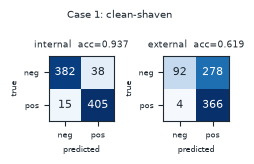

split          acc    prec     rec      F1      AUC     ECE    TP   FP   TN   FN
internal     0.937   0.914   0.964   0.939   0.9845   0.013   405   38  382   15
external     0.619   0.568   0.989   0.722   0.8459   0.250   366  278   92    4


In [10]:
def draw_confusion(ax, labels, probabilities, title):
    """Confusion matrix with the count printed in every cell.

    A heatmap alone shows the shape of the errors; the counts are what the written analysis
    quotes, so they belong inside the figure rather than in a separate printout.
    """
    tp, fp, tn, fn = counts(labels, probabilities)
    matrix = np.array([[tn, fp], [fn, tp]])
    ax.imshow(matrix, cmap='Blues', vmin=0, vmax=matrix.max())
    for row in range(2):
        for column in range(2):
            value = matrix[row, column]
            ax.text(column, row, f'{value}', ha='center', va='center', fontsize=8,
                    color='white' if value > matrix.max() * 0.55 else INK)
    short = [name[:3] for name in class_names]
    ax.set_xticks([0, 1], short, fontsize=6); ax.set_yticks([0, 1], short, fontsize=6)
    ax.set_xlabel('predicted', fontsize=6); ax.set_ylabel('true', fontsize=6)
    ax.set_title(title, fontsize=6.5)

scores = {split: metrics(results[split]['labels'], results[split]['prob_pos'])
          for split in results}

# Drawn at 2.4 inches because that is roughly the width it occupies in the report. A figure scaled
# down from 7 inches into a column has labels nobody can read.
figure, axes = plt.subplots(1, 2, figsize=(2.4, 1.5))
for ax, split in zip(axes, ('internal', 'external')):
    draw_confusion(ax, results[split]['labels'], results[split]['prob_pos'],
                   f"{split}  acc={scores[split]['acc']:.3f}")
figure.suptitle(f'Case {CASE}: {POSITIVE_CLASS}', fontsize=7)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.94))
figure.savefig(f'case{CASE}_confusion.png', dpi=150, bbox_inches='tight')
figure.savefig(f'case{CASE}_confusion.pdf', bbox_inches='tight')
plt.show()

header = f"{'split':10s}{'acc':>8}{'prec':>8}{'rec':>8}{'F1':>8}{'AUC':>9}{'ECE':>8}"
print(header + f"{'TP':>6}{'FP':>5}{'TN':>5}{'FN':>5}")
for split in ('internal', 'external'):
    s = scores[split]
    # AUC at four places: three would round 0.9997 to a perfect 1.000 and overstate the result.
    print(f"{split:10s}{s['acc']:8.3f}{s['prec']:8.3f}{s['rec']:8.3f}{s['f1']:8.3f}"
          f"{s['auc']:9.4f}{s['ece']:8.3f}{s['tp']:6d}{s['fp']:5d}{s['tn']:5d}{s['fn']:5d}")

## 8. Where the predicted probabilities sit

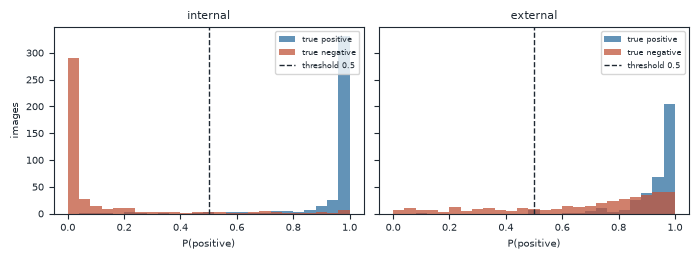

In [11]:
# A classifier that has kept its grip pushes the two classes to opposite ends of the axis. Mass
# collapsing to the middle, or one class crossing the threshold, localises what went wrong.
figure, axes = plt.subplots(1, 2, figsize=(7.0, 2.6), sharey=True)
for ax, split in zip(axes, ('internal', 'external')):
    labels = results[split]['labels'].astype(bool)
    probabilities = results[split]['prob_pos']
    ax.hist(probabilities[labels], bins=25, range=(0, 1), alpha=0.75, color=ACCENT,
            label=f'true {class_names[1]}')
    ax.hist(probabilities[~labels], bins=25, range=(0, 1), alpha=0.75, color=WARM,
            label=f'true {class_names[0]}')
    ax.axvline(0.5, color=INK, ls='--', lw=1, label='threshold 0.5')
    ax.set_title(split, fontsize=8); ax.set_xlabel(f'P({class_names[1]})')
    ax.legend(fontsize=6)
axes[0].set_ylabel('images')
figure.tight_layout()
figure.savefig(f'case{CASE}_prob_dist.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. ROC and AUC

Accuracy and the confusion matrix both depend on the 0.5 threshold. AUC does not, so comparing the
two tells whether the model has lost the ability to separate the classes or merely to place the
boundary.

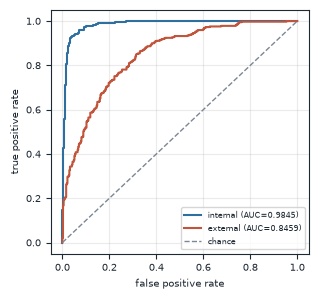

AUC internal=0.9845   external=0.8459


In [12]:
# ROC is threshold-free, so it separates "the scores no longer rank the classes" from "the scores
# still rank them but 0.5 is now the wrong place to cut".
figure, ax = plt.subplots(figsize=(3.2, 3.0))
for split, colour in (('internal', ACCENT), ('external', WARM)):
    false_positive_rate, true_positive_rate, _ = roc_curve(results[split]['labels'],
                                                           results[split]['prob_pos'])
    ax.plot(false_positive_rate, true_positive_rate, color=colour,
            label=f"{split} (AUC={scores[split]['auc']:.4f})")
ax.plot([0, 1], [0, 1], color=MUTED, ls='--', lw=1, label='chance')
ax.set_xlabel('false positive rate'); ax.set_ylabel('true positive rate')
ax.legend(fontsize=6); ax.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(f'case{CASE}_roc.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"AUC internal={scores['internal']['auc']:.4f}   "
      f"external={scores['external']['auc']:.4f}")

## 10. Calibration, and what the most confident predictions are worth

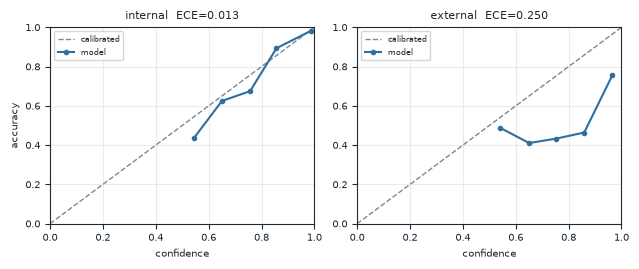

split        gate  published  accuracy
internal     0.90      84.0%     0.982
internal     0.99      55.7%     0.989
external     0.90      55.0%     0.757
external     0.99      15.8%     0.932


In [13]:
figure, axes = plt.subplots(1, 2, figsize=(6.4, 2.7))
for ax, split in zip(axes, ('internal', 'external')):
    mean_confidence, accuracy, weight, ece = expected_calibration_error(
        results[split]['labels'], results[split]['prob_pos'])
    ax.plot([0, 1], [0, 1], color=MUTED, ls='--', lw=1, label='calibrated')
    ax.plot(mean_confidence, accuracy, marker='o', ms=3, color=ACCENT, label='model')
    ax.set_title(f'{split}  ECE={ece:.3f}', fontsize=8)
    ax.set_xlabel('confidence'); ax.set_xlim(0, 1); ax.set_ylim(0, 1)
    ax.legend(fontsize=6); ax.grid(alpha=0.25)
axes[0].set_ylabel('accuracy')
figure.tight_layout()
figure.savefig(f'case{CASE}_reliability.png', dpi=150, bbox_inches='tight')
plt.show()

# The number the bypass design actually depends on: among predictions the gate would publish
# without review, how many are right?
print(f"{'split':10s}{'gate':>7}{'published':>11}{'accuracy':>10}")
for split in ('internal', 'external'):
    labels, probabilities = results[split]['labels'], results[split]['prob_pos']
    confidence = np.maximum(probabilities, 1 - probabilities)
    correct = (probabilities > 0.5).astype(int) == labels
    for gate in (0.90, 0.99):
        selected = confidence >= gate
        accuracy = correct[selected].mean() if selected.any() else float('nan')
        print(f'{split:10s}{gate:7.2f}{selected.mean() * 100:10.1f}%{accuracy:10.3f}')

### 10.1 Accuracy against coverage

Sorting predictions by confidence and taking a running accuracy traces every operating point a
confidence threshold can reach, which is the quantity a review-bypass depends on.

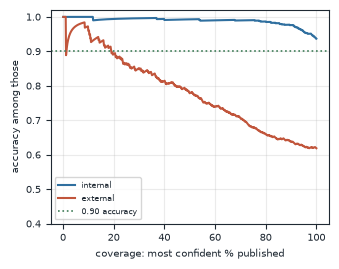

split       coverage  accuracy
internal         10%     1.000
internal         25%     0.995
internal         50%     0.993
internal        100%     0.937
internal    best accuracy at any coverage above 5%: 1.000
external         10%     0.959
external         25%     0.865
external         50%     0.778
external        100%     0.619
external    best accuracy at any coverage above 5%: 0.984


In [14]:
def risk_coverage(labels, probabilities):
    """Accuracy achievable if only the most confident fraction of predictions is acted on.

    Sorting by confidence and taking a running mean of correctness traces every operating point
    a confidence gate can reach. Because any calibration is monotone in the score, it moves the
    threshold that selects a coverage but never this curve, so the curve is the real ceiling.
    """
    confidence = np.maximum(probabilities, 1 - probabilities)
    correct = ((probabilities > 0.5).astype(int) == labels).astype(float)
    order = np.argsort(-confidence)
    coverage = np.arange(1, len(labels) + 1) / len(labels)
    return coverage, np.cumsum(correct[order]) / np.arange(1, len(labels) + 1)

figure, ax = plt.subplots(figsize=(3.4, 2.7))
for split, colour in (('internal', ACCENT), ('external', WARM)):
    coverage, accuracy = risk_coverage(results[split]['labels'], results[split]['prob_pos'])
    ax.plot(coverage * 100, accuracy, color=colour, label=split)
ax.axhline(0.90, color=GREEN, ls=':', lw=1.2, label='0.90 accuracy')
ax.set_xlabel('coverage: most confident % published'); ax.set_ylabel('accuracy among those')
ax.set_ylim(0.4, 1.02); ax.legend(fontsize=6); ax.grid(alpha=0.25)
figure.tight_layout()
figure.savefig(f'case{CASE}_risk_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"{'split':10s}{'coverage':>10}{'accuracy':>10}")
for split in ('internal', 'external'):
    coverage, accuracy = risk_coverage(results[split]['labels'], results[split]['prob_pos'])
    for target in (0.10, 0.25, 0.50, 1.00):
        # ceil rather than searchsorted: the point at exactly this coverage, not the one below it.
        index = max(0, int(np.ceil(target * len(coverage))) - 1)
        print(f'{split:10s}{coverage[index] * 100:9.0f}%{accuracy[index]:10.3f}')
    best = accuracy[coverage >= 0.05].max()
    print(f'{split:10s}  best accuracy at any coverage above 5%: {best:.3f}')

## 11. Class activation maps

Metrics say how often the model is wrong. CAM shows what it was looking at when it was, which is
the evidence that separates a model attending to the target attribute from one keying on
something that merely accompanies it.

In [15]:
# Class activation mapping, as in the week 5 tutorial: the last convolutional block's feature maps
# weighted by the classifier weights for the predicted class, which shows which regions of the
# image drove that prediction.
features = {}
model.layer4[1].register_forward_hook(
    lambda module, inputs, output: features.__setitem__('maps', output.detach()))
head_weights = model.state_dict()['fc.weight']

@torch.no_grad()
def class_activation_map(image):
    """Return the predicted class, its confidence, and the upsampled activation map."""
    logits = model(image.unsqueeze(0).to(device))
    predicted = int(logits.argmax(1))
    confidence = float(torch.softmax(logits, 1).max())
    cam = torch.sum(head_weights[predicted][:, None, None] * features['maps'][0], dim=0)
    cam = cam.clamp(min=0)
    cam = cam / (cam.max() + 1e-8)
    cam = torch.nn.functional.interpolate(cam[None, None], size=(224, 224), mode='bilinear',
                                          align_corners=False)
    return predicted, confidence, cam.squeeze().cpu().numpy()

def denormalise(image):
    """Undo the ImageNet normalisation so the tensor can be displayed."""
    return np.clip(image.numpy().transpose(1, 2, 0) * IMAGENET_STD + IMAGENET_MEAN, 0, 1)

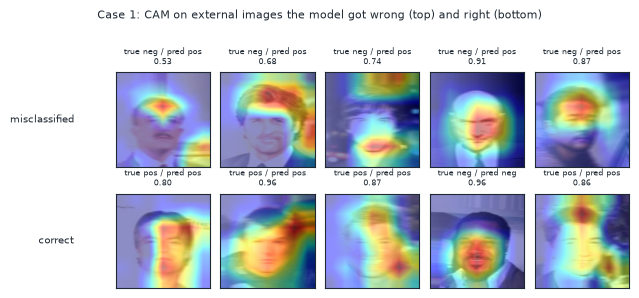

external errors: 282 of 740


In [16]:
# Sampling at random would show whatever the model happens to be doing on average. The question is
# what it does when it is WRONG, so the two rows are drawn from the errors and from the correct
# predictions on the same split and the same true class.
external = datasets['external']
labels, probabilities = results['external']['labels'], results['external']['prob_pos']
predicted_labels = (probabilities > 0.5).astype(int)
wrong = np.where(predicted_labels != labels)[0]
right = np.where(predicted_labels == labels)[0]

COLUMNS = 5
rng = np.random.default_rng(3)
groups = [('misclassified', rng.choice(wrong, min(COLUMNS, len(wrong)), replace=False)),
          ('correct', rng.choice(right, min(COLUMNS, len(right)), replace=False))]
figure, axes = plt.subplots(2, COLUMNS, figsize=(6.4, 3.0))
for row, (title, indices) in enumerate(groups):
    for ax, index in zip(axes[row], indices):
        image, true_label = external[index]
        predicted, confidence, cam = class_activation_map(image)
        ax.imshow(denormalise(image))
        ax.imshow(cam, cmap='jet', alpha=0.45)
        ax.set_xticks([]); ax.set_yticks([])
        ax.set_title(f'true {class_names[true_label][:3]} / pred {class_names[predicted][:3]}'
                     f'\n{confidence:.2f}', fontsize=6)
    axes[row][0].set_ylabel(title, fontsize=7, rotation=0, ha='right', va='center', labelpad=30)
figure.suptitle(f'Case {CASE}: CAM on external images the model got wrong (top) and right (bottom)',
                fontsize=8)
figure.tight_layout(rect=(0.0, 0.0, 1.0, 0.95))
figure.savefig(f'case{CASE}_cam.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'external errors: {len(wrong)} of {len(labels)}')

In [17]:
# CelebA images are aligned, so the same pixel rows hold the same part of every face: the eyes sit
# just above the middle and the jaw near the bottom. Splitting the activation map into three bands
# and averaging over many images turns "where is it looking" into a number that can be compared
# between the predictions the model got right and the ones it got wrong.
BANDS = [('forehead and hair', 0, 75), ('eyes and nose', 75, 150), ('mouth and jaw', 150, 224)]

def band_mass(indices, dataset, limit=60):
    """Mean share of activation-map mass falling in each horizontal band of the face."""
    totals = np.zeros(len(BANDS))
    for index in indices[:limit]:
        image, _ = dataset[int(index)]
        _, _, cam = class_activation_map(image)
        share = np.array([cam[low:high].sum() for _, low, high in BANDS])
        totals += share / share.sum()
    return totals / min(limit, len(indices))

print(f"{'external predictions':22s}" + ''.join(f'{name:>20}' for name, _, _ in BANDS))
for title, indices in (('misclassified', wrong), ('correct', right)):
    shares = band_mass(indices, external)
    print(f'{title:22s}' + ''.join(f'{value:20.3f}' for value in shares))

external predictions     forehead and hair       eyes and nose       mouth and jaw


misclassified                        0.242               0.431               0.327


correct                              0.042               0.416               0.542


## 12. Controlled experiment: reproduce the field failure in the laboratory

Section 4 measured two differences between the splits: the external images carry far less
high-frequency detail and are considerably brighter. Measuring a difference is not the same as
showing it causes the failure, and the external set also contains different people, which is an
alternative explanation on its own.

The experiment separates them. The **internal** images are degraded, so their
subjects and labels are held fixed and the picture is the only thing that changes. Blur is swept
across a range of strengths and the brightness shift is applied on its own as a control. If loss of
detail is the cause, accuracy should fall along the sweep and pass through the field result while
keeping its shape. If the failure is really about *who* the field photographs contain, no amount of
degradation will reproduce it.

In [18]:
# The degradation is applied to the INTERNAL images, so the people and the labels are held fixed
# and the only thing that changes is the picture. Blur is applied before the resize, at capture
# resolution, because that is where a weaker camera loses detail. The brightness shift is additive
# so it moves the level without also flattening contrast.
SHIFT = round(external_bright - internal_bright, 2)
SIGMAS = (0.0, 0.5, 1.0, 2.0, 3.0, 4.0)

def degraded_loader(blur_sigma=0.0, brightness_shift=0.0):
    """The internal split, optionally blurred and brightened, through the delivered pipeline."""
    steps = [transforms.ToTensor()]
    if blur_sigma:
        steps.append(transforms.GaussianBlur(int(2 * round(3 * blur_sigma) + 1), blur_sigma))
    if brightness_shift:
        steps.append(transforms.Lambda(lambda t: (t + brightness_shift).clamp(0, 1)))
    steps += [transforms.Resize((224, 224), antialias=True),
              transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    dataset = torchvision.datasets.ImageFolder(os.path.join(DATA_ROOT, 'test_internal'),
                                               transform=transforms.Compose(steps))
    return torch.utils.data.DataLoader(dataset, batch_size=32, shuffle=False, num_workers=0)

def tensor_sharpness(loader, limit=64):
    """Sharpness measured after the pipeline, so degraded and field images are comparable."""
    values = []
    for images, _ in loader:
        for image in images:
            grey = (image * torch.tensor(IMAGENET_STD)[:, None, None]
                    + torch.tensor(IMAGENET_MEAN)[:, None, None]).mean(0).numpy()
            values.append(laplacian_variance(grey))
            if len(values) >= limit:
                return float(np.mean(values))
    return float(np.mean(values))

FIELD_SHARPNESS = tensor_sharpness(loaders['external'])
print(f'field sharpness after the pipeline: {FIELD_SHARPNESS:.5f}')
print(f'brightness shift to be tested as a control: {SHIFT:+.2f}')

field sharpness after the pipeline: 0.00058
brightness shift to be tested as a control: +0.26


Gaussian blur is a stand-in for whatever the mobile capture path does,
not a claim about it. What the sweep establishes does not depend on the two matching in mechanism:
if removing detail from the studio images, and nothing else, walks their accuracy down through the
field result while preserving its shape, then loss of detail is sufficient to produce the failure
and the change of subjects is not needed to explain it.

In [19]:
def score(loader):
    """Full metric set for one version of the internal split."""
    labels, probabilities = collect(loader)
    return metrics(labels, probabilities)

# One row per blur strength, then the brightness shift on its own as a control. If detail loss is
# the cause, accuracy should fall along this sweep and pass through the field result while keeping
# its shape: false positives climbing and recall staying near 1.
sweep = {}
print(f"{'condition':22s}{'sharpness':>11}{'acc':>8}{'prec':>8}{'rec':>8}{'FP':>6}{'FN':>6}")
for sigma in SIGMAS:
    loader = loaders['internal'] if sigma == 0 else degraded_loader(blur_sigma=sigma)
    result = score(loader)
    result['sharpness'] = tensor_sharpness(loader)
    sweep[sigma] = result
    print(f"{'blur sigma ' + format(sigma, '.1f'):22s}{result['sharpness']:11.5f}"
          f"{result['acc']:8.3f}{result['prec']:8.3f}{result['rec']:8.3f}"
          f"{result['fp']:6d}{result['fn']:6d}")

BRIGHT_ONLY = score(degraded_loader(brightness_shift=SHIFT))
BRIGHT_ONLY['sharpness'] = tensor_sharpness(degraded_loader(brightness_shift=SHIFT))
print(f"{'brightness ' + format(SHIFT, '+.2f') + ' only':22s}{BRIGHT_ONLY['sharpness']:11.5f}"
      f"{BRIGHT_ONLY['acc']:8.3f}{BRIGHT_ONLY['prec']:8.3f}{BRIGHT_ONLY['rec']:8.3f}"
      f"{BRIGHT_ONLY['fp']:6d}{BRIGHT_ONLY['fn']:6d}")
field = scores['external']
print(f"{'field, for comparison':22s}{FIELD_SHARPNESS:11.5f}{field['acc']:8.3f}"
      f"{field['prec']:8.3f}{field['rec']:8.3f}{field['fp']:6d}{field['fn']:6d}")

# The blur that lands closest to the field accuracy, reported rather than chosen in advance.
MATCH = min(SIGMAS, key=lambda s: abs(sweep[s]['acc'] - field['acc']))
print(f"\nclosest match: blur sigma {MATCH:.1f} gives accuracy {sweep[MATCH]['acc']:.3f} and "
      f"{sweep[MATCH]['fp']} false positives")
print(f"the field gives accuracy {field['acc']:.3f} and {field['fp']} false positives")
print(f"brightness alone reaches only {BRIGHT_ONLY['acc']:.3f}, so exposure is not the cause")

condition               sharpness     acc    prec     rec    FP    FN


blur sigma 0.0            0.00394   0.937   0.914   0.964    38    15


blur sigma 0.5            0.00198   0.931   0.897   0.974    47    11


blur sigma 1.0            0.00044   0.887   0.818   0.995    93     2


blur sigma 2.0            0.00007   0.750   0.667   0.998   209     1


blur sigma 3.0            0.00002   0.670   0.604   0.986   271     6


blur sigma 4.0            0.00001   0.620   0.570   0.979   310     9


brightness +0.26 only     0.00336   0.918   0.874   0.976    59    10
field, for comparison     0.00058   0.619   0.568   0.989   278     4

closest match: blur sigma 4.0 gives accuracy 0.620 and 310 false positives
the field gives accuracy 0.619 and 278 false positives
brightness alone reaches only 0.918, so exposure is not the cause


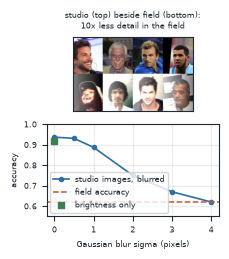

In [20]:
# The report panel for this case, drawn at the width the report gives it: what the field images
# look like beside the studio ones, and what blurring the studio images does to the model.
figure, axes = plt.subplots(2, 1, figsize=(2.3, 2.6),
                            gridspec_kw={'height_ratios': [1.0, 1.25]})

# Sized so the strip fills the width the panel already reserves. imshow fits the image to
# whichever axis binds first; below five columns that is the height, so these extra faces are
# drawn at the same size as before and merely occupy margin that was blank.
STRIP = 4
rng = np.random.default_rng(11)
rows = []
for split in ('internal', 'external'):
    paths = paths_by_folder[(split, class_names[0])]
    picked = rng.choice(len(paths), STRIP, replace=False)
    rows.append(np.hstack([np.asarray(Image.open(paths[i]).resize((89, 109))) for i in picked]))
axes[0].imshow(np.vstack(rows))
axes[0].set_xticks([]); axes[0].set_yticks([])
axes[0].set_title(f'studio (top) beside field (bottom):\n'
                  f'{internal_sharp / external_sharp:.0f}x less detail in the field', fontsize=6)

accuracies = [sweep[s]['acc'] for s in SIGMAS]
axes[1].plot(SIGMAS, accuracies, marker='o', ms=3, lw=1.2, color=ACCENT,
             label='studio images, blurred')
axes[1].axhline(scores['external']['acc'], color=WARM, ls='--', lw=1.1, label='field accuracy')
axes[1].plot([0], [BRIGHT_ONLY['acc']], marker='s', ms=4, color=GREEN, ls='none',
             label='brightness only')
axes[1].set_xlabel('Gaussian blur sigma (pixels)', fontsize=6)
axes[1].set_ylabel('accuracy', fontsize=6)
axes[1].set_ylim(0.55, 1.0); axes[1].tick_params(labelsize=6)
axes[1].legend(fontsize=5.5, loc='lower left'); axes[1].grid(alpha=0.25)

figure.tight_layout()
figure.savefig(f'case{CASE}_evidence.png', dpi=200, bbox_inches='tight')
figure.savefig(f'case{CASE}_evidence.pdf', bbox_inches='tight')
plt.show()

## 13. Findings

**Diagnosis: texture dependency, caused by a capture-quality shift between studio and mobile.**
The classifier reads "clean-shaven" from fine stubble texture on the chin and jaw. The mobile
images carry roughly a tenth of the internal set's high-frequency detail, so that texture is gone,
and faces that are not clean-shaven no longer look any different from ones that are.

**Experiments and evidence.** Three results agree. First, the splits differ in exactly the way the
diagnosis requires: at identical pixel dimensions and file format, the field images carry an order
of magnitude less high-frequency detail and are markedly brighter, while the same measurement on
cases 2 and 3 shows no comparable gap, so the difference is a property of this case rather than of
how it was measured. Second, the errors are one-sided in the direction that texture loss predicts.
Almost every additional error is a false positive and recall *rises* towards 1, which is what
happens when faces that are not clean-shaven stop looking different from ones that are.

Third, and decisively, the sweep in Section 12 walks the internal set down to the field result by
blurring it and nothing else. Accuracy falls monotonically with blur and passes through the field
accuracy, and it arrives there with the same shape: false positives climbing into the hundreds
while false negatives stay in single figures. The brightness shift on its own barely moves
accuracy, so exposure is a difference between the splits but not the cause of the failure.

That sweep is what separates this diagnosis from its alternatives. The people and the
labels are identical at every point on it, so had the failure been caused by the field set
containing different or harder subjects, degrading the studio images could not have reproduced it.

The saliency bands agree and add a detail. On the field images the model gets right, most of the
activation falls on the mouth and jaw, which is where a beard would be. On the ones it gets wrong
that share drops by roughly a third and the map spreads upward into the forehead and hair, a region
that carries almost none of its attention when it succeeds. Once blur has removed the texture, the
region that should decide the prediction no longer holds anything to decide it with, and the model
falls back on whatever structure survives.

**Recommendations.** Retraining is out of scope here, so the recommendation is ordered by what the
team can act on immediately. Deploy a sharpness gate at inference: the Laplacian variance of an
incoming frame is one cheap statistic, and frames below the studio range should be refused with a
prompt to retake rather than scored. Second, match the pre-processing to the capture path so the
model is not asked to read detail the camera did not record. Third, and the real fix, extend the
training set with mobile-quality captures and validate on a held-out mobile sample, since a
detector for a texture cue can only be trusted on images that preserve the texture.